# Q-Learning Walkthrough

A short notebook that trains the `QLearningAgent` for a few episodes and shows the training curves and Q-policy heatmap.
Edit the `episodes` variable below to run longer experiments.

In [1]:
import sys
from pathlib import Path

# Add project root to path so imports work
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from envs import MazeEnv
from agents import QLearningAgent
from training import Trainer, get_q_learning_config

# Create environment and agent
env = MazeEnv(difficulty="hard") # You can change difficulty to "easy" , "medium" or "hard" to see different mazes
agent = QLearningAgent(env=env, **get_q_learning_config())
trainer = Trainer(env=env, agent=agent)

episodes = 2000 # change to a larger number to train longer

In [2]:
# Run training (short)
logger = trainer.train(n_episodes=episodes, verbose=True, verbose_interval=max(1, episodes//5))
print('Training finished. Episodes logged:', len(logger.rewards))

Episode   400/2000 | Reward:   -5.75 | Success Rate: 96.0% | Steps:   44
Episode   800/2000 | Reward:    9.18 | Success Rate: 100.0% | Steps:   32
Episode  1200/2000 | Reward:    9.61 | Success Rate: 100.0% | Steps:   33
Episode  1600/2000 | Reward:    9.61 | Success Rate: 100.0% | Steps:   32
Episode  2000/2000 | Reward:    9.61 | Success Rate: 100.0% | Steps:   32
Training finished. Episodes logged: 2000


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Q-Learning Policy Heatmap'}>)

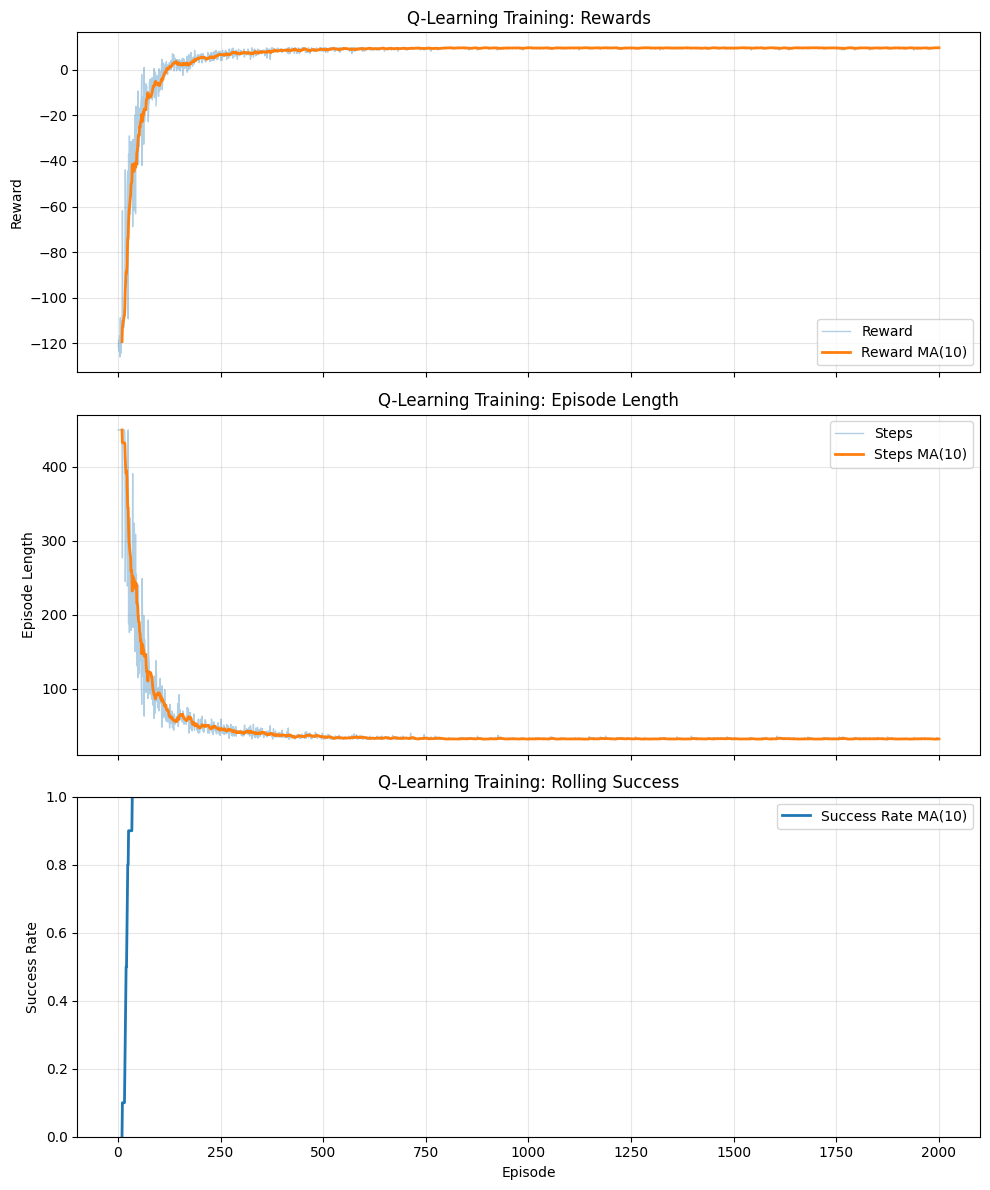

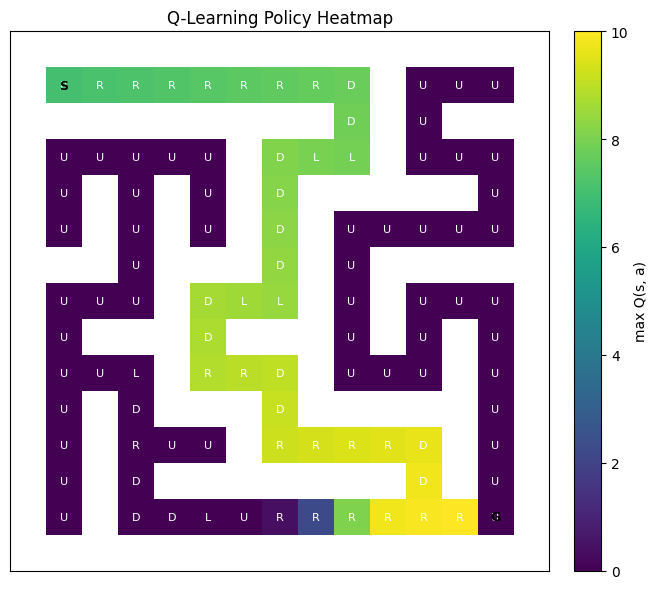

In [3]:
# Plot training curves and policy heatmap
trainer.plot_training(moving_average_window=10)
trainer.plot_q_policy_heatmap()

You can export results programmatically using the `trainer.logger.export_csv()` method and the trainer's plotting helpers.